<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Algoritmos e Avaliação em Agrupamento</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a> e <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> 

 <hr style="height:2px"> 

## Introdução

Análise de Agrupamento é uma forma de aprendizado não supervisionado, que tem como objetivo a identificação de uma estrutura de _clusters_ (grupos) dentro de um conjunto de dados. Técnicas de agrupamento devem encontrar estas estruturas, de forma que os objetos pertencentes de um mesmo _cluster_ compartilhem características em comum. Em outras palavras, a análise de agrupamento busca, de forma inteligente, descobrir padrões dentro de um conjunto de dados, usando estes padrões para separá-los e agrupá-los.

Por não possuir um resultado esperado, em oposição ao aprendizado supervisionado, a análise de agrupamento se torna bastante complexa: para um determinado conjunto de dados em uma aplicação real, não existe uma estrutura de grupos - ou partição - verdadeira, dificultando a avaliação do resultado obtido por diferentes algoritmos de agrupamento.

Adicionalmente, não se tem um conceito definitivo do que é um *cluster*, existindo então agrupamentos de variados formatos e com características completamente diferentes entre si. Por esse motivo, algoritmos da área possuem estratégias diferentes de agrupamento, cada uma encontrando estruturas com uma determinada característica.

Ao longo deste *notebook*, serão aplicados diferentes algoritmos de agrupamento, cada qual com sua abordagem para agrupar os dados, sobre três conjuntos de dados diferentes entre si. Após a execução das técnicas, será realizada uma avaliação dos resultados obtidos. Dessa forma, será possível acompanhar um processo simples de agrupamento de dados e análise das partições obtidas. 

Ao final do *notebook*, espera-se que o leitor assimile qual algoritmo é melhor para cada critério de avaliação ou tipo de estrutura desejada, entenda que não há algoritmo ou índice avaliativo superior ao outro de forma geral, e consiga reproduzir a análise realizada.

Este notebook se refere aos Capítulos **12 (Análise de Agrupamentos)**, **13 (Algoritmos de Agrupamento)** e **15 (Avaliação de Modelos Descritivos)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/3.1.1/index.html) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scipy`](https://www.scipy.org) (versão 1.2.1 ou superior): conjunto de funções úteis para Ciência de Dados
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 0.22.2 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial

A biblioteca [`os`](https://docs.python.org/3/library/os.html), para realizar tarefas específicas ao Sistema Operacional, também será utilizada. Por fazer parte da [Biblioteca Padrão de Python](https://docs.python.org/pt-br/3/library/), sua instalação não é necessária.

Serão utilizados também os conjuntos de dados disponibilizados junto com este *notebook*, que se encontram no diretório `datasets`, em formato de arquivo `.csv`.

In [1]:
# -*- coding: utf-8 -*-

# Bibliotecas
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import chebyshev, cityblock, cosine, euclidean
from scipy.stats import pearsonr
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, SpectralClustering
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline

DATASETS_DIR = 'datasets'

---
## Funções auxiliares

Nesta célula, estão implementadas diversas funções que serão utilizadas repetidamente ao longo do _notebook_. São elas:

**`colorize`**: recebe um vetor de rótulos (`data`) em formato de `list` ou `numpy.ndarray` e retorna um vetor de códigos HTML para cores em `numpy.ndarray`, para ser usado nos gráficos. **Obs**.: embora bibliotecas de gráficos, como a `matplotlib`, disponibilizem maneiras de colorir seus gráficos, suas paletas de cores não são adequadas para daltonismo. A função contorna este problema;

**`load_dataset`**: recebe o nome de um dos conjuntos de dados de _datasets_ (`dataset_name`) em formato `str` e carrega como um objeto do tipo `pandas.DataFrame`;

**`plot_multiple_datasets`**: recebe um conjunto de bases de dados (`dataset`) em formato `list` ou `numpy.ndarray` de `pandas.DataFrame`, e gera o gráfico de cada um dos conjuntos de dados. A disposição dos gráficos deve ser definida através de `nrows` (qt. de linhas) e `ncols` (qt. de colunas). Se informado, estiliza as amostras do conjunto de dados de acordo com os rótulos passados por `cluster_labels` em formato de `list` ou `numpy.ndarray`. Caso não seja passado nada para `cluster_labels`, estiliza de acordo com a coluna de rótulos reais de cada base de dados. Pode receber um título geral para os gráficos (`suptitle`).

**`plot_multiple_partitions`**: recebe uma base de dados (`dataset`) em formato `pandas.DataFrame` e múltiplas partições (`cluster_labels`) em `list` ou `numpy.ndarray`, e gera o gráfico de cada uma destas partições. A disposição dos gráficos deve ser definida através de `nrows` (qt. de linhas) e `ncols` (qt. de colunas). Pode receber um título geral (`suptitle`) e títulos específicos por gráfico (`subtitles`);

In [2]:
def colorize(data):
    color_palette = ['#910101', '#036CD7', '#078F8F', '#000000', '#FDFD6F', '#B16FFD', '#22FF25',
                     '#074752', '#8F4A00', '#FE6FB5', '#6BB6FE', '#DF6B00', '#48018D', '#FCB5DA']
    labels = np.unique(data)
    if len(labels) > len(color_palette):
        color_palette += ["#%06x" % c for c in np.random.randint(0, 0xFFFFFF, len(labels)-len(color_palette))]
    color_array = np.empty(data.shape, dtype=object)
    for label, color in zip(labels, color_palette):
        color_array[np.where(data==label)] = color
    return color_array


def load_dataset(dataset_name):
    dataset = pd.read_csv(os.path.join(DATASETS_DIR, dataset_name+'.csv'), sep=';')
    dataset.name = dataset_name
    dataset.n_clusters = dataset['cluster'].nunique()
    return dataset

    
def plot_multiple_datasets(datasets, nrows, ncols, cluster_labels=None, suptitle=None):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(min(5*ncols, 12), 3*nrows), constrained_layout=True)
    ax = ax.flatten()
    for i, dataset in enumerate(datasets):
        clusters = dataset['cluster'] if cluster_labels is None else cluster_labels[i]        
        ax[i].scatter(dataset['d1'], dataset['d2'], s=10, c=colorize(clusters))            
        ax[i].set_title('{0} - {1} clusters'.format(dataset.name, len(np.unique(clusters))))
        ax[i].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=16)    
    plt.show()
    

def plot_multiple_partitions(dataset, cluster_labels, nrows, ncols, suptitle=None, subtitles=None):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(min(5*ncols, 12), 3*nrows), constrained_layout=True)
    ax = ax.flatten()
    for i, clusters in enumerate(cluster_labels):        
        ax[i].scatter(dataset['d1'], dataset['d2'], s=10, c=colorize(clusters))            
        if subtitles is not None:
            ax[i].set_title(subtitles[i])
        ax[i].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=16)
    plt.show()

---
## Bases de Dados

Para os experimentos, foram selecionados três conjuntos de dados diferentes, presentes na pasta `datasets` em formato `.csv`. Os três arquivos possuem uma coluna com um identificador único para cada objeto (`id`), dois atributos (`d1` e `d2`), e um rótulo indicando a qual grupo pertencem (`cluster`). Tem-se então que, para os três conjuntos, as estruturas reais são conhecidas (e bastante intuitivas para o olhar humano). São eles:

* **globulars**: 1000 objetos divididos em 2 _clusters_ baseados em centro, com formato esférico;

* **spirals**: 1000 objetos divididos em 2 _clusters_ encadeados, com formato em espiral;

* **monkey**: 4000 objetos divididos em 8 *clusters*, cada um com características e formatos diferentes, compondo o rosto de um macaquinho.

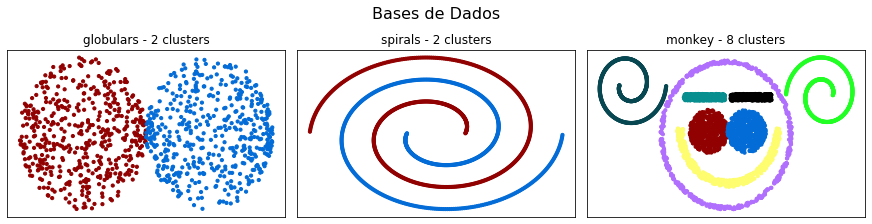

In [3]:
globulars, spirals, monkey = load_dataset('globulars'), load_dataset('spirals'), load_dataset('monkey')
datasets = [globulars, spirals, monkey]
plot_multiple_datasets(datasets, suptitle='Bases de Dados', nrows=1, ncols=3)

---
## Medidas de proximidade

Muitos algoritmos de agrupamento e métricas de avaliação trabalham com conceitos de distância e similaridade entre objetos. É importante ter conhecimento sobre como diferentes medidas de proximidade funcionam, pois a escolha da medida utilizada pelo algoritmo pode gerar partições bastantes diferentes entre si.

Para o entendimento do assunto, as medidas de proximidade mais comuns da área serão calculadas entre dois objetos $x_0$ e $x_1$, exibidos abaixo. Os dois objetos possuem a mesma dimensionalidade. O objeto $x_0$ é representado pelo vetor $(1,2)$ e $x_1$ pelo vetor $(4, 3.5)$.

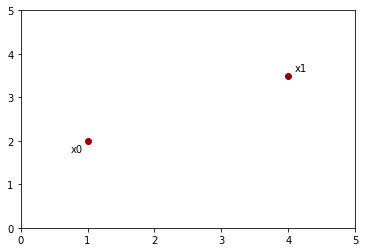

In [4]:
x = np.array([[1.0, 2.0],
              [4.0, 3.5]])

fig, ax = plt.subplots()
ax.scatter(x[:,0], x[:,1], c='#910101')
ax.annotate('x0', x[0] - 0.25)
ax.annotate('x1', x[1] + 0.10)
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
plt.show()

Serão calculadas sobre os objetos três medidas de **distância** e duas de **similaridade**.

Além de diferenças em suas formulações teóricas, pode-se dizer que uma das principais diferenças entre medidas de distância e similaridade é a maneira como o resultado deve ser analisado. Para medidas de **distância**, objetos diferentes encontram-se mais distantes um do outro, sendo $0$ a distância entre dois objetos iguais. Já para medidas de **similaridade**, valores menores indicam objetos menos semelhantes. Em outras palavras, dois objetos parecidos tendem a ter uma **distância menor** e uma **similaridade maior**.

Todas as medidas principais da área possuem implementação pronta em bibliotecas como `sklearn`, `scipy` ou `numpy`.

#### Medidas de distância
* **Distância de Manhattan** (ou distância bloco-cidade): implementada em `scipy.spatial.distance.cityblock`; dada pela Equação: $$d(x_i, x_j) = \sum^d_{l=1}{|x_i^l - x_j^l|}$$

* **Distância Euclidiana**: implementada em `scipy.spatial.distance.euclidian`; dada pela Equação: $$d(x_i, x_j) = \sqrt{\sum^d_{l=1}{(x_i^l - x_j^l)^2}}$$

* **Distância Chebyshev** (ou *supremum*): implementada em `scipy.spatial.distance.chebyshev`; dada pela Equação: $$d(x_i, x_j) = \max_{1 \le l \le d}{|x_i^l - x_j^l|}$$


#### Medidas de similaridade
* **Cosseno**: implementada em formato de distância em `scipy.spatial.distance.cosine`, dada pela Equação: $$cosseno(x_i, x_j) = \frac{\sum^d_{l=1}{x_i^l x_j^l}}{\sqrt{\sum^d_{l=1}{{x_i^l}^2} \sum^d_{l=1}{{x_j^l}^2}}}$$

* **Correlação de Pearson**: implementada em `scipy.stats.pearsonr`, dada pela Equação: $$pearson(x_i, x_j) = \frac{\sum^d_{l=1}{(x^l_i-\bar{x_i})(x^l_j-\bar{x_j})}}{\sqrt{\sum^d_{l=1}{(x^l_i-\bar{x_i})^2} \sum^d_{l=1}{(x^l_j-\bar{x_j})^2} }}$$


**Desafio:** antes de seguir para a próxima célula, que contém os valores de cada medida aplicadas sobre $x_0$ e $x_1$, tente calculá-los por conta própria, para depois comparar o resultado. Isso ajudará no aprendizado e no entendimento das medidas.

In [5]:
#--------------------------------------------------------------------------------------------------
# MEDIDADES DE DISTÂNCIA

manhattan_dist = cityblock(x[0], x[1])
euclidian_dist = euclidean(x[0], x[1])
chebyshev_dist = chebyshev(x[0], x[1])

print('Medidas de Proximidade')
print('\tDistância de Manhattan: {:.3f}'.format(manhattan_dist))
print('\t  Distância Euclidiana: {:.3f}'.format(euclidian_dist))
print('\tDistância de Chebyshev: {:.3f}'.format(chebyshev_dist))

print('\n')

#--------------------------------------------------------------------------------------------------
# MEDIDADES DE SIMILARIDADE

cosine_similarity = 1 - cosine(x[0], x[1])
pearson_correlation = pearsonr(x[0], x[1])[0]

print('Medidas de Similaridade')
print('\t\t       Cosseno: {:.3f}'.format(cosine_similarity))
print('\t Correlação de Pearson: {:.3f}'.format(pearson_correlation))

Medidas de Proximidade
	Distância de Manhattan: 4.500
	  Distância Euclidiana: 3.354
	Distância de Chebyshev: 3.000


Medidas de Similaridade
		       Cosseno: 0.926
	 Correlação de Pearson: -1.000


---
## Algoritmos

Existem vários algoritmos de agrupamento, cada um se utilizando de um critério de agrupamento para encontrar uma estrutura sobre os dados do conjunto estudado. Nos casos onde a partição real dos dados segue o mesmo critério que a do algoritmo aplicado, a estrutura real de _clusters_ pode ser encontrada. Por esse motivo, ao trabalhar com conjuntos de dados cujo agrupamento real é desconhecido, torna-se bastante importante aplicar algoritmos de estratégias diferentes, e analisar o resultado de cada um.

Ao longo das próximas células, serão executados diferentes algoritmos nas bases `globulars`, `spirals` e `monkey`. Os algoritmos foram divididos em 4 grupos, **hierárquicos**, **particionais baseado em erro quadrático**, **baseado em densidade** e **baseados em grafo**, de acordo com a forma que cada um realiza o agrupamento.

Para todos os algoritmos, será aplicada como medida de distância entre os objetos a **distância euclidiana**, que é a distância padrão nas implementações da biblioteca utilizada.

### Hierárquico

Algoritmos hierárquicos utilizam métricas de integração para gerar os grupos, e recebem como entrada uma matriz de distância entre os objetos do conjunto de dados

Podem adotar duas estratégias: aglomerativa ou divisiva. Na primeira, a execução é iniciada com $N$ *clusters*, cada um com apenas uma amostra. Estes são depois unidos sucessivamente, formando uma sequência de partições. A segunda funciona de forma contrária, começando com um único _cluster_ com todos os objetos, e dividindo-o sucessivamente.

A biblioteca `scikit-learn` possui uma implementação de algoritmo aglomerativo, presente em `sklearn.cluster.AgglomerativeClustering`. Através do parâmetro `linkage`, é possível alterar a métrica de integração, gerando algoritmos diferentes. São eles:

* **Single-link**, quando `linkage=single`: une os _clusters_ baseado na ligação mínima entre amostras de _clusters_ diferentes;
* **Complete-link**, quando `linkage=complete`: une os _clusters_ baseado na ligação máxima entre amostras de _clusters_ diferentes;
* **Average-link**, quando `linkage=average`: une os _clusters_ baseado na ligação média entre amostras de _clusters_ diferentes.

**Obs.:** é interessante reparar nas partições geradas por cada algoritmo e exibidas abaixo, como a escolha da métrica de integração altera o resultado final.

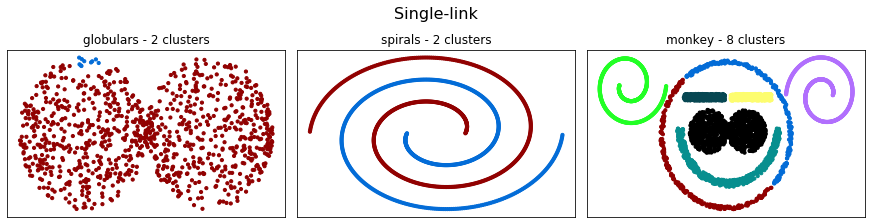

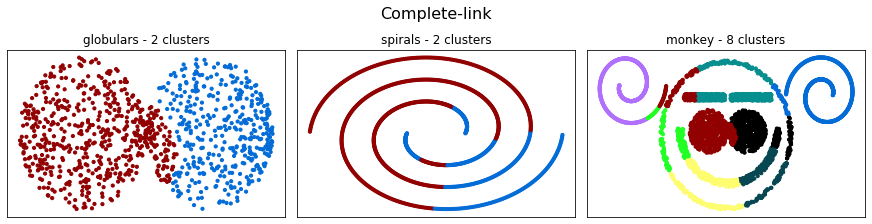

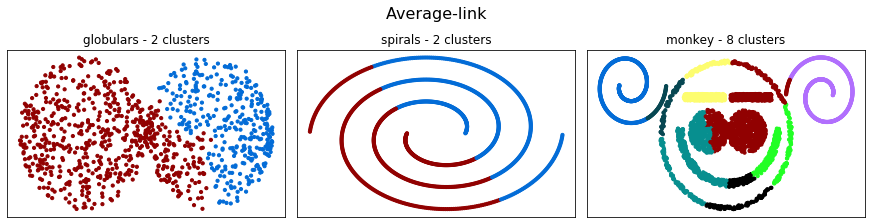

In [6]:
for linkage_type in ['single', 'complete', 'average']:
    cluster_labels = list()
    for dataset in datasets:
        model = AgglomerativeClustering(linkage=linkage_type, n_clusters=dataset.n_clusters)
        pred_clusters = model.fit_predict(dataset[['d1', 'd2']])
        cluster_labels.append(pred_clusters)
    plot_multiple_datasets(datasets, cluster_labels=cluster_labels, 
                           suptitle=linkage_type.capitalize()+'-link', nrows=1, ncols=3)

#### Visualizando a sequência de partições pelo Dendrograma

Para visualizar como o agrupamento de um algoritmo hierárquico foi realizado, é comumente utilizado o dendrograma. Neste tipo de gráfico, a hieraquia de agrupamento é representado como uma árvore binária: as folhas da árvore contém os objetos do conjunto, os nós internos representam os _clusters_ e as arestas mostram a ligação realizada entre dois _clusters_ em cada etapa do algoritmo.

Através da função `scipy.cluster.hierarchy.linkage` é possível construir uma matriz de ligação, definindo a métrica de integração da mesma forma que no algoritmo `AgglomerativeClustering`. A matriz de ligação pode servir então como entrada em `scipy.cluster.hierarchy.dendrogram`, para gerar a visualização do dendrograma.

Abaixo, foram gerados os dendrogramas para os algoritmos *Single-link*, _Complete-link_ e *Average-link*, sobre um conjunto de dados de 8 objetos, gerados aleatoriamente.

**Obs.:** um exercício interessante para avaliar seu entendimento das métricas de integração é observar os 8 objetos do conjunto e desenhar manualmente os dendrogramas construídos por cada algoritmo, para depois comparar com os dendrogramas gerados pelo método `dendrogram`.

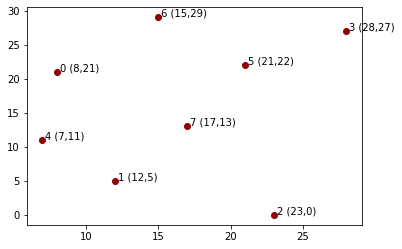

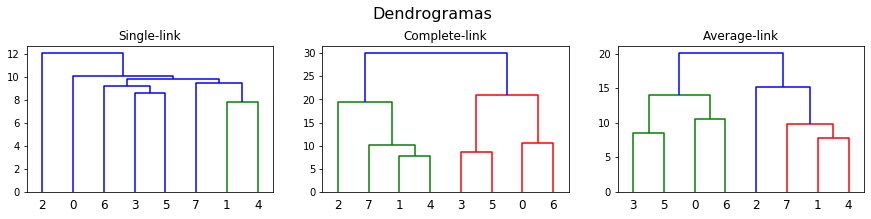

In [7]:
np.random.seed(15)
x = np.random.randint(0, 31, (8,2))

fig, ax = plt.subplots()
ax.scatter(x[:,0], x[:,1], c='#910101')
for i in range(8):
    ax.annotate('{} ({},{})'.format(i, x[i,0], x[i,1]), x[i]+0.2)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
fig.suptitle('Dendrogramas', fontsize=16)
fig.subplots_adjust(top=0.8)
for i, linkage_type in enumerate(['single', 'complete', 'average']):
    ax[i].set_title('{}-link'.format(linkage_type.capitalize()))
    dn = hierarchy.dendrogram(hierarchy.linkage(x, linkage_type), ax=ax[i])

### Algoritmos Particionais Baseados em Erro Quadrático

Algoritmos que otimizam o critério de agrupamento de forma iterativa. Possuem um critério que deve ser otimizado através da transição de objetos entre _clusters_. 

O critério de agrupamento adotado por estes algoritmos é o erro quadrático, relacionado a compactação dos _clusters_. Dessa forma, em cada iteração, o algoritmo agrupa os objetos de forma a diminuir o erro quadrático médio entre cada objeto e o centróide de seu respectivo _cluster_.

O algoritmo particional baseado em erro quadrático mais tradicional é o **K-Médias**, implementado na biblioteca `scikit-learn` em `sklearn.cluster.KMeans`.

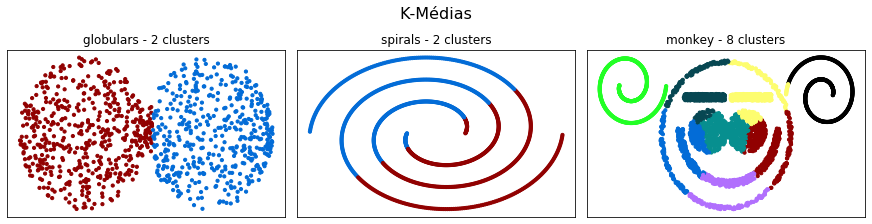

In [8]:
cluster_labels = list()
for dataset in datasets:
    model = KMeans(n_clusters=dataset.n_clusters)
    pred_clusters = model.fit_predict(dataset[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
plot_multiple_datasets(datasets, cluster_labels=cluster_labels, suptitle='K-Médias', nrows=1, ncols=3)

#### Centróide?

É muito comum entre algoritmos de agrupamento, especialmente para os particionais baseados em erro quadrático, o conceito de centróide do _cluster_.

Um centróide $\bar{x}$ de um _cluster_ $k$ corresponde a média (como na Equação abaixo) ou a mediana de cada atributo entre todos os objetos de um mesmo _cluster_.

$$\bar{x}^{(k)} = \frac{1}{n_k}\sum_{x_i \in C_k}{x_i}$$

Abaixo, um conjunto de dados foi gerado aleatoriamente, e separado em dois grupos. Em seguida, o centróide de cada grupo foi calculado e exibido, na cor preta, em formato de triângulo.

Amostras do cluster 0
[[2 6]
 [1 9]
 [2 8]
 [3 7]]
Centróide:  [2.  7.5] 

Amostras do cluster 1
[[8 6]
 [8 8]
 [7 7]
 [7 5]]
Centróide:  [7.5 6.5] 



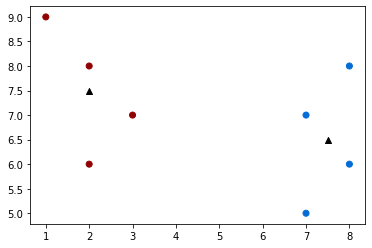

In [9]:
x, y = make_blobs(n_samples=8, cluster_std=1, random_state=20, centers=2)
x = np.round(x).astype(int)

print('Amostras do cluster 0')
print(x[np.where(y==0)])
print('Centróide: ', np.mean(x[np.where(y==0)], axis=0), '\n')

print('Amostras do cluster 1')
print(x[np.where(y==1)])
print('Centróide: ', np.mean(x[np.where(y==1)], axis=0), '\n')

centroids = np.vstack([np.mean(x[np.where(y==0)], axis=0), np.mean(x[np.where(y==1)], axis=0)])
plt.scatter(x[:,0], x[:,1], c=colorize(y))
plt.scatter(centroids[:, 0], centroids[:, 1], c='Black', marker='^')
plt.show()

### Algoritmos Baseados em Densidade

Algoritmos baseados em densidade consideram _clusters_ como regiões de alta densidade de objetos, separadas por regiões de baixa densidade. Pela forma como funcionam, possuem a vantagem de crescer os _clusters_ para qualquer lado, podendo encontrar estruturas de formatos arbitrários.

O algoritmo de agrupamento baseado em densidade mais tradicional é o **DBSCAN**, implementado em `sklearn.cluster.DBSCAN`. Diferente dos algoritmos executados acima, o DBSCAN não permite a escolha do número de _clusters_ da partição. Pelo contrário, o algoritmo encontra a quantidade de _clusters_ de forma automática, baseado nas regiões densas de objetos. 

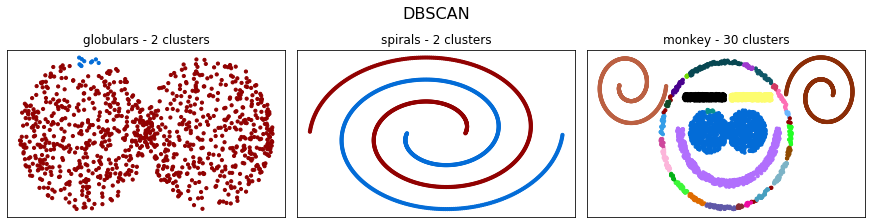

In [10]:
cluster_labels = list()
for dataset in datasets:
    model = DBSCAN()
    pred_clusters = model.fit_predict(dataset[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
plot_multiple_datasets(datasets, cluster_labels=cluster_labels, suptitle='DBSCAN', nrows=1, ncols=3)

#### Usando o DBSCAN para detecção de _outliers_

Uma característica que pode ser utilizada para diferenciar algoritmos de agrupamento é como cada um trabalha com ruídos e *outliers*: objetos que possuem comportamento significativamente diferente dos demais.

Certo algoritmos, como os hierárquicos, são bastante sensíveis a _outliers_. Outros, como os baseados em densidade e em grade, possuem mais robustez para esse problema.

O DBSCAN é um algoritmo que lida bem com *outliers*, podendo ser utilizado para detectá-los. Na implementação da biblioteca `scikit-learn`, pode-se utilizar a função `fit_predict` ou `predict` para detectar simultaneamente os _clusters_ e *outliers*, sendo os últimos marcados com rótulo -1.

Na visualização abaixo, os _outliers_ encontram-se na cor preta, em formato de estrela.

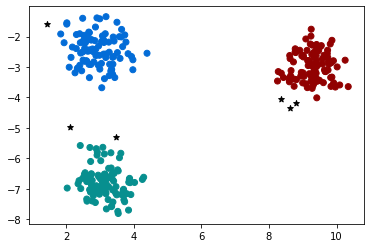

In [11]:
x = make_blobs(n_samples=300, cluster_std=0.5, random_state=30)[0]
model = DBSCAN()
pred_clusters = model.fit_predict(x)

labeled_samples = np.where(pred_clusters!=-1)
noisy_samples = np.where(pred_clusters==-1)

plt.scatter(x[labeled_samples,0], x[labeled_samples,1], c=colorize(pred_clusters[labeled_samples]))
plt.scatter(x[noisy_samples,0], x[noisy_samples,1], c='Black', marker='*')
plt.show()

### Algoritmos Baseados em Grafo

Algoritmos baseados em grafos usam conceitos de teoria dos grafos para representar o conjunto de dados. Tradicionalmente, cada objeto é tratado como um vértice, conectado aos demais objetos por $n-1$ arestas, nas quais os pesos carregam a similaridade ou distância entre os dados

O **Spectral Clustering** é um algoritmo baseado em grafo que gera uma matriz de afinidade entre as amostras, converte-as para uma dimensão reduzida e aplica um algoritmo K-Médias tradicional. Encontra-se implementado em `sklearn.cluster.SpectralClustering`.

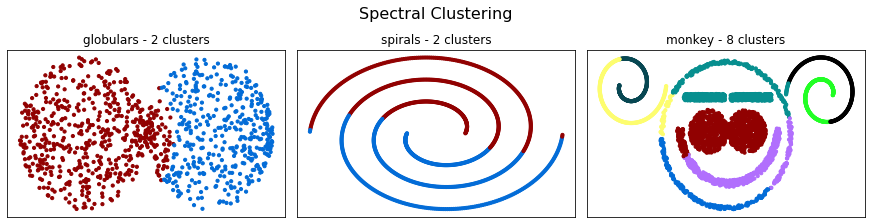

In [12]:
cluster_labels = list()
for dataset in datasets:
    model = SpectralClustering(n_clusters=dataset.n_clusters)
    pred_clusters = model.fit_predict(dataset[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
plot_multiple_datasets(datasets, cluster_labels=cluster_labels, suptitle='Spectral Clustering', nrows=1, ncols=3)

### Outros tipos de algoritmo de agrupamento

Algoritmos de agrupamentos ainda podem ser classificados como **Baseados em Redes Neurais** e **Baseados em _Grid_ (Grade)**. O primeiro se utiliza de Redes Neurais Artificiais para gerar o agrupamento, enquanto o segundo constrói um _grid_ para o espaço de dados e realiza as operações sobre ele.

Por não possuírem implementação pronta na biblioteca `scikit-learn`, ao contrário dos demais, a execução de algoritmos baseados de redes neurais ou em _grid_ foge do escopo deste _notebook_. Entretanto, alguns encontram-se implementados em outras bibliotecas da linguagem Python, ou disponibilizados publicamente em repositórios de código. Fica a critério do leitor estudar mais e se aprofundar na área.

**Algoritmos baseados em Redes Neurais**: existem diversas implementações de _SOMs_ (*Self Organizing Maps*) para a linguagem Python. Como melhores avalidas, encontram-se: [MiniSom](https://github.com/JustGlowing/minisom), implementada por Giuseppe Vettigli; [Kohonen_SOM_Tensorflow](https://github.com/spiglerg/Kohonen_SOM_Tensorflow), implementada por Giacomo Spigler; e [pyERA](https://github.com/mpatacchiola/pyERA), implementada por Massimiliano Patacchiola.

**Algoritmos baseados em _Grid_**: [gpumafia](https://github.com/canonizer/gpumafia), algoritmo MAFIA (*Merging of Adaptive Finite Intervals*), implementado por Andy Adinets; [Clique](https://github.com/georgekatona/Clique), algoritmo CLIQUE (*Clustering In QUEst*), implementado por György Katona.

Adicionalmente, muitos algoritmos de agrupamento, das mais variadas categorias e estratégias de agrupamento, encontram-se implementados em Python e C++ na biblioteca [PyClustering](https://github.com/annoviko/pyclustering), de Andrei Novikov.

---
## Avaliação de Modelos Descritivos

Na análise de agrupamento, a avaliação e comparação de resultados pode ser feita sob dois pontos de vista: comparação de algoritmos de agrupamento e validação das estruturas encontradas.

Durante a avaliação dos resultados obtidos, é importante lembrar que a análise de agrupamento é uma tarefa não supervisionada. Dessa forma, não há uma partição correta (um objetivo a ser alcançado), mas sim partições que encontraram melhores estuturas nos dados segundo algum critério determinado.

Ao analisar agrupamentos gerados, são utilizados **índices** sobre os dados, que avaliam **critérios**. Um critério de validação expressa a estratégia utilizada para validar uma estrutura de agrupamento, enquanto um ı́ndice é uma estatı́stica pela qual a validade é testada.

Critérios e índices podem ser divididos em três grupos: **relativos**, **internos** e **externos**. A seguir, índices bastante utilizados na área encontram-se aplicados sobre partições geradas pelos algoritmos K-Médias, Single-link, Complete-link e Average-link.

### Critérios Relativos / Internos

O objetivo da validação **relativa** é encontrar qual agrupamento melhor se adapta aos dados, considerando algum determinado aspecto, podendo ser utilizada para determinar o número de _clusters_ mais apropriados.

Os critérios **internos** medem a qualidade do agrupamento baseando-se nos dados originais, como a matriz de objeto ou de distância/similaridade.

Muitas vezes, índices relativos podem ser utilizados para análise interna.

Serão utilizados três índices tradicionalmente empregados em critérios relativos e internos. São eles:

* **Variância Intracluster (VAR)**: mede o grau de compactação dos _clusters_ de uma partição $\pi$. Valores menores indicam _clusters_ mais compactos, com menor variância entre as amostras. Não possui implementação pelas bibliotecas que estão sendo utilizadas, e é calculado através da Equação: 

$$var(\pi) = \sqrt{\frac{1}{n}\sum_{C_k \in \pi}{\sum_{x_i \in C_k}{d(x_i, \bar{x}^{(k)})}}}$$

* **Conectividade (CON)**: mede o encadeamento dos _clusters_ de uma partição $\pi$, mensurando o grau com que objetos vizinhos são agrupados em um mesmo _cluster_. Valores menores indicam _clusters_ mais conectados. Assim como a VAR, não possui implementação pronta. É dado pela Equação abaixo, em que $v$ é o número de vizinhos mais próximos que serão considerados e $nn_{ij}$ é o $j$-ésimo vizinho mais próximo a $x_i$. 

$$con(\pi) = \sum_{x_i \in X}{\sum_{j=1}^v{f(x_i, nn_{ij})}}$$ 

$$f(x_i, nn_{ij}) = \begin{cases} \frac{1}{j} \; \text{se} \; x_i \in C_k, nn_{ij} \notin C_k \\ 0 \; \text{caso contrário} \end{cases}$$

* **Silhueta (SIL)**: mede o quanto objetos de um mesmo _cluster_ se encontram compactados, e quão distantes se encontram dos objetos do _cluster_ mais próximo. Desta maneira, avalia a adequação de cada objeto para seu _cluster_ e a qualidade de cada _cluster_ individualmente. Varia entre $[-1, 1]$, sendo $1$ o melhor valor possível, e é um índice bastante usado para estimar o número de _clusters_ mais apropriado. Possui implementação na biblioteca `scikit-learn`, em `sklearn.metrics.cluster.silhouette_score`. Para calcular a silhueta da partição $\pi$, deve-se calcular a silhueta de cada _cluster_ $C_k$. Por sua vez, para calcular a silhueta de cada _cluster_ $C_k$, é necessário calcular a silhueta de cada objeto $x_i \in C_k$. Assim, utilizam-se as seguintes Equações: 

$$sil(x_i) = \begin{cases} 1 - a(x_i, C_k)/b(x_i), \quad\;\;\; a(x_i, C_k) \lt b(x_i) \\ 0, \qquad\qquad\qquad\qquad a(x_i, C_k) = b(x_i) \\ b(x_i)/a(x_i, C_k)-1, \quad\;\;\; a(x_i, C_k) \gt b(x_i)\end{cases}$$

$$a(x_i, C_k) = \frac{1}{\mid C_k \mid} \sum_{x_i, x_j \in C_k \\ \;\, x_i \ne x_j}{d(x_i, x_j)}$$

$$b(x_i) = \min_{x_i \in C_k, \\ C_k \ne C_j}{a(x_i, C_j)}$$

$$sil(C_k) = \frac{1}{\mid C_k \mid}\sum_{x_i \in C_k}{sil(x_i)}$$

$$sil(\pi) = \frac{1}{n}\sum_{i=1}^n{sil(x_i)}$$

**Nota sobre a implementação:** para a conectividade, foi implementada uma versão vetorizada, que gera o mesmo resultado da Equação apresentada, mas de maneira mais eficiente. Adicionalmente, para a conectividade e a silhueta, podem ser adotadas diferentes medidas de distância. Neste *notebook*, será utilizada distância euclidiana.

In [13]:
def intracluster_variance(data, clusters):
    centroids = data.groupby(clusters).mean()
    distances = np.sqrt(data.set_index(clusters).subtract(centroids).pow(2).sum(axis=1))
    return np.sqrt(distances.mean())

def connectivity(data, clusters, v):
    distances = euclidean_distances(data)
    neighbors = distances.argsort(axis=0)[1:v+1]
    neighbors_labels = clusters[neighbors]
    diff_clusters = (clusters != neighbors_labels).astype(int)
    return (diff_clusters/np.arange(1, v+1).reshape(v, 1)).sum()

from sklearn.metrics.cluster import silhouette_score

### Critérios Externos

A validação **externa** busca validar o agrupamento obtido quando comparado com uma hipótese pré-estabelecida. Neste *notebook*, iremos comparar as partições obtidas por cada algoritmo com a partição real dos dados.

O índice mais tradicional na validação externa é o **índice Rand (RI)**, que faz uma comparação nos objetos par-a-par, verificando se os mesmos se encontram agrupados no mesmo _cluster_ em ambas partições ou não. Considerando duas partições $\pi^e$ e $\pi^r$, cada par de objetos $(x_i, x_j)$ pode ser classificado de 4 formas:
* SS: se $x_i$ e $x_j$ pertencem ao mesmo _cluster_ em $\pi^e$ e $\pi^r$;
* SD: se $x_i$ e $x_j$ pertencem ao mesmo _cluster_ em $\pi^e$ e _clusters_ diferentes em $\pi^r$;
* DS: se $x_i$ e $x_j$ pertencem a _clusters_ diferentes em $\pi^e$ e ao mesmo _cluster_ em $\pi^r$;
* DD: se $x_i$ e $x_j$ pertencem a _clusters_ diferentes em $\pi^e$ e $\pi^r$

Sendo $M$ o número total de pares possíveis ($n(n-1)/2$), $a_1$ o número de pares SS, $a_2$ o número de pares SD, $a_3$ o número de pares DS e $a_4$ o número de pares DD, o índice Rand entre $\pi^e$ e $\pi^r$ pode ser calculado como:

$$RI(\pi^e,\pi^r) = \frac{(a_1 + a_4)}{M}$$

O índice Rand possui uma variação, o **índice Rand Corrigido (ARI)**, que se tornou a mais utilizada para essa finalidade. Nela, o valor do índice pode variar entre $[-1, 1]$, sendo $0$ para partições geradas ao acaso e $1$ para partições idênticas. O índice encontra-se implementado em `sklearn.metrics.cluster.adjusted_rand_score`.

In [14]:
from sklearn.metrics.cluster import adjusted_rand_score

### Aplicação dos Critérios de Avaliação

A seguir, foram executados 4 algoritmos (**K-Médias**, **Sigle-link**, **Complete-link** e **Average-link**) sobre as 3 bases de dados (**globulars**, **spirals** e **monkey**), gerando diversas partições com número de _clusters_ diferentes. Os índices supracitados foram aplicados sobre as partições geradas, e foi realizada uma análise de comparação entre os resultados obtidos por cada algoritmo.

Inicialmente, foi implementada uma função, `evaluate_clusters`, apenas para reaproveitamento de código entre todos os conjuntos de dados. A função recebe como entrada um conjunto de dados (`dataset`) e uma lista de quantidades de _clusters_ (`clusters_sizes`), criando gráficos para cada partição gerada e uma tabela com os resultados dos índices.

In [15]:
def evaluate_clusters(dataset, clusters_sizes):
    score_results = dict()
    cluster_labels = list()
    subtitles = list()
    for n_clusters in clusters_sizes:
        score_results[n_clusters] = dict()
        models = [
            ('K-Médias', KMeans(n_clusters=n_clusters)), 
            ('Single-link', AgglomerativeClustering(n_clusters=n_clusters, linkage='single')),
            ('Complete-link', AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')),
            ('Average-link', AgglomerativeClustering(n_clusters=n_clusters, linkage='average'))
        ]    
        for model_name, model in models:            
            pred_clusters = model.fit_predict(dataset[['d1', 'd2']])
            cluster_labels.append(pred_clusters)

            var = intracluster_variance(dataset[['d1', 'd2']], pred_clusters)
            con = connectivity(dataset[['d1', 'd2']], pred_clusters, 10)
            sil = silhouette_score(dataset[['d1', 'd2']], pred_clusters)
            ari = adjusted_rand_score(dataset['cluster'], pred_clusters)
            
            subtitles.append('{} - {} clusters\nVAR = {:.3f} | CON = {:.3f}\nSIL = {:.3f} | ARI = {:.3f}'.format(model_name, n_clusters, var, con, sil, ari))
            
            score_results[n_clusters][model_name] = {
                'Var. Intracluster (VAR)': var, 'Conectividade (CON)': con, 
                'Silhueta (SIL)': sil, 'Ind. Rand Corrigido (ARI)': ari
            }
            
    plot_multiple_partitions(dataset, cluster_labels=cluster_labels, nrows=len(clusters_sizes), ncols=4, subtitles=subtitles)
    
    results_table = pd.DataFrame.from_dict({(i,j): score_results[i][j] for i in score_results.keys() for j in score_results[i].keys()}, orient='index')
    return results_table

### Conjunto de dados _globulars_
 
O conjunto `globulars` possui dois _clusters_ esféricos e compactos. Dessa forma, **é esperado que as melhores partições sejam aquelas geradas por algoritmos que possuem como estratégia de agrupamento a redução da variância intracluster**.

É possível perceber um exemplo disso através da variância intracluster (VAR) e do índice Rand corrigido (ARI) para partições de 2 *clusters*: o algoritmo que obteve o melhor ARI e a menor VAR foi o K-Médias, encontrando a partição que mais se assemelhou ao agrupamento real dos dados e maximizando a compatação do agrupamento. Entretanto, não se pode tomar isso como verdade absoluta. Para todas as partições com 3 ou mais *clusters*, o Complete-link e o Average-link se alternaram entre aquele que obteve o maior ARI, enquanto o K-Médias continuou sempre apresentando a menor VAR.

Entre os 4 algoritmos, o Single-link foi aquele que obteve os piores resultados, apresentando sempre ARI igual a zero. Foi o algoritmo que gerou agrupamentos com maior variância intracluster e alcançou valores baixos de silhueta. Era o esperado, por se tratar de um algoritmo baseado no encadeamento. Por este mesmo motivo, foi o que apresentou menores valores para a conectividade.

Por fim, para esse exemplo, percebe-se que a silhueta era um bom índice para encontrar o número de _clusters_ mais apropriados, visto que alcançou valores mais próximos de 1 quando $k = 2$. Em adição, poderia ter sido utilizado para encontrar a melhor partição, no caso do agrupamento real não ser conhecido, já que apresentou o melhor resultado na mesma partição que alcançou o maior ARI (K-médias com 2 *clusters*).

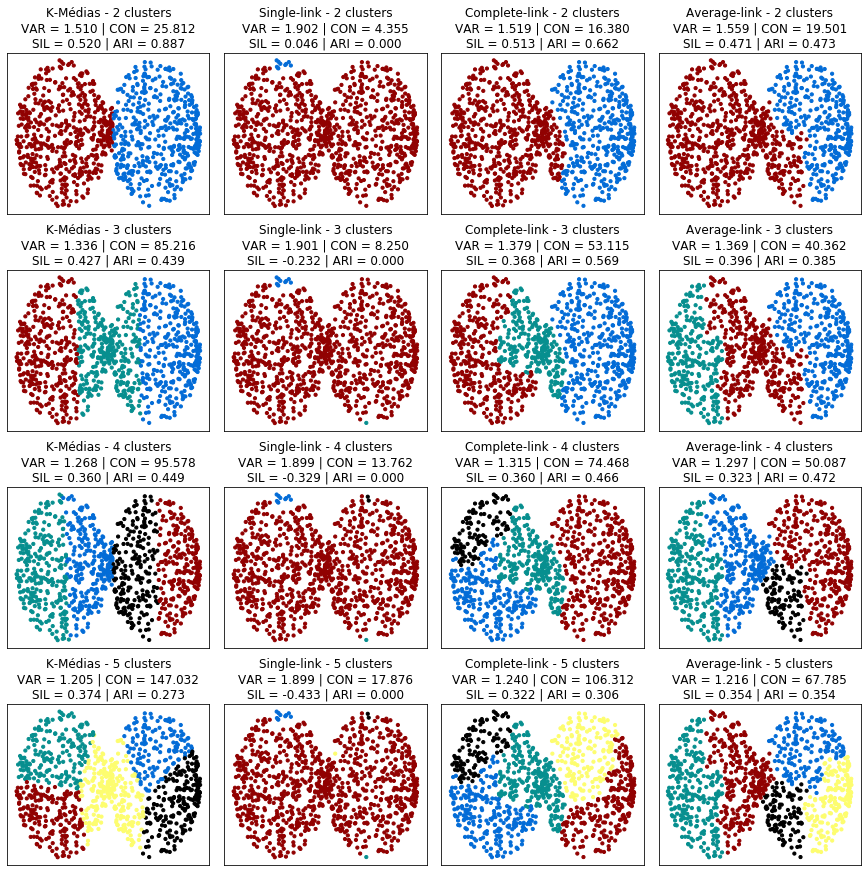

Var. Intracluster (VAR)  Conectividade (CON)  Silhueta (SIL)  \
2 K-Médias                      1.510165            25.811905        0.520167   
  Single-link                   1.902339             4.354762        0.045521   
  Complete-link                 1.518736            16.380159        0.512687   
  Average-link                  1.558650            19.501190        0.470815   
3 K-Médias                      1.335923            85.216270        0.426913   
  Single-link                   1.901227             8.250397       -0.231713   
  Complete-link                 1.379216            53.115476        0.367930   
  Average-link                  1.369310            40.361905        0.396004   
4 K-Médias                      1.267705            95.577778        0.360189   
  Single-link                   1.899009            13.762302       -0.328999   
  Complete-link                 1.315310            74.468254        0.359517   
  Average-link                  1.296936            50.086508        0.322956   
5 K-Médias                      1.205370           147.032143        0.373647   
  Single-link                   1.898599            17.875794       -0.433492   
  Complete-link                 1.239806           106.311905        0.321625   
  Average-link                  1.216312            67.784524        0.354207   

                 Ind. Rand Corrigido (ARI)  
2 K-Médias                        0.887252  
  Single-link                     0.000360  
  Complete-link                   0.662270  
  Average-link                    0.472868  
3 K-Médias                        0.439063  
  Single-link                     0.000320  
  Complete-link                   0.568742  
  Average-link                    0.385175  
4 K-Médias                        0.449323  
  Single-link                     0.000257  
  Complete-link                   0.466410  
  Average-link                    0.471802  
5 K-Médias                        0.273012  
  Single-link                     0.000229  
  Complete-link                   0.306352  
  Average-link                    0.353796

In [16]:
results_globulars = evaluate_clusters(dataset=globulars, clusters_sizes=range(2, 6))
display(results_globulars)

### Conjunto de dados _spirals_

O conjunto de dados `spirals` é composto por dois _clusters_ fortemente encadeados, em formato de espiral. Neste caso, em oposição ao anterior, **algoritmos que reduzem a conectividade (CON) tendem a ser aqueles que melhor se comportam sobre os dados**.

Como esperado, o Single-link foi o que reduziu a CON e encontrou a melhor partição, chegando a agrupar todos os dados da mesma forma que no agrupamento real, e obtendo 1 como ARI (para $k = 2$). Os demais algoritmos apresentaram VAR menor que o Single-link, mas, devido ao comportamento das estruturas reais, todos apresentaram valores baixíssimos para o ARI.

Três pontos interessantes podem ser percebidos com a análise destes resultados:

1. Ao analisar os resultados em conjunto com aquele obtido sobre a base `globulars`, percebe-se que um algoritmo que reduz a variância intracluster não necessariamento é o melhor. O mesmo ocorre com aquele que reduz a conectividade. Tudo depende das estruturas de agrupamento reais dos dados;

2. Mesmo que o Complete-link e o Average-link sejam algoritmos hierárquicos, assim como o Single-link, não é esperado que os três se comportem de forma parecida nos índices. Cada algoritmo possui uma estratégia de agrupamento, que gera resultados bastante diferentes;

3. Diferente do caso acima, a silhueta não encontrou nem o número mais apropriado de _clusters_ (obtendo o maior valor para o K-Médias com 4 _clusters_) e nem a melhor partição (alcançando o piores valores para o Single-link, que teve o melhor ARI). Tal fato evidencia como não é possível utilizar a silhueta como único índice para decidir o melhor agrupamento.

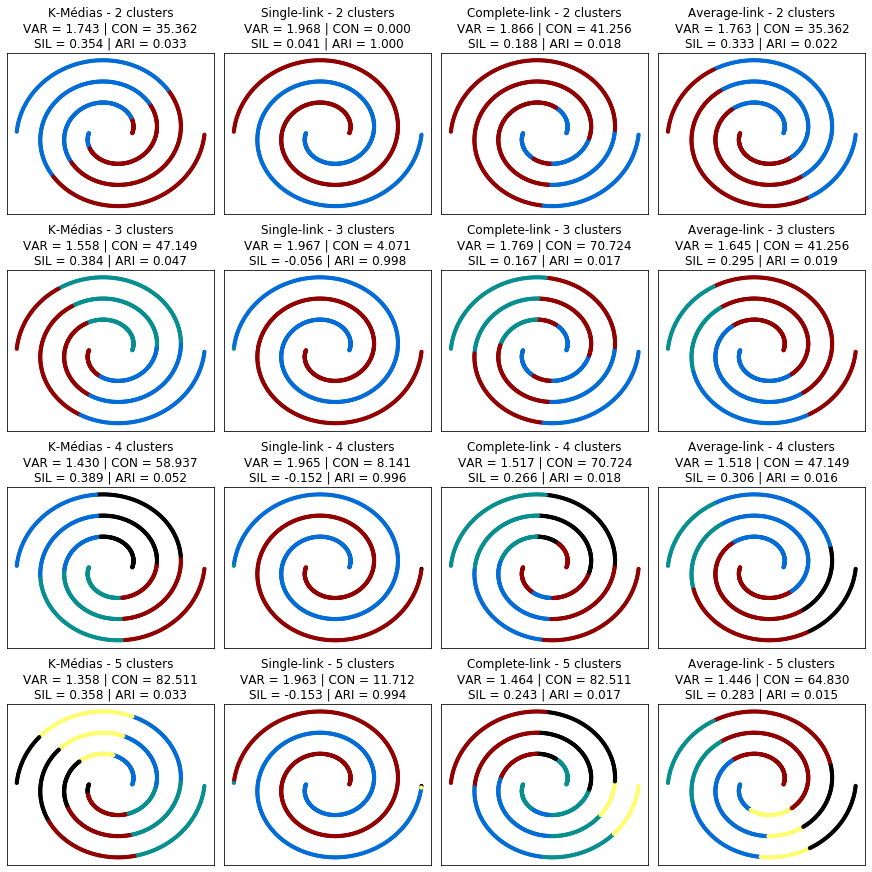

Var. Intracluster (VAR)  Conectividade (CON)  Silhueta (SIL)  \
2 K-Médias                      1.742910            35.361905        0.353623   
  Single-link                   1.968333             0.000000        0.040672   
  Complete-link                 1.866407            41.255556        0.187773   
  Average-link                  1.763341            35.361905        0.332980   
3 K-Médias                      1.557894            47.149206        0.383559   
  Single-link                   1.966647             4.070635       -0.055713   
  Complete-link                 1.769479            70.723810        0.167103   
  Average-link                  1.645272            41.255556        0.295423   
4 K-Médias                      1.429954            58.936508        0.389456   
  Single-link                   1.964959             8.141270       -0.151783   
  Complete-link                 1.517240            70.723810        0.265670   
  Average-link                  1.518048            47.149206        0.306297   
5 K-Médias                      1.358449            82.511111        0.357724   
  Single-link                   1.963275            11.711905       -0.152757   
  Complete-link                 1.464260            82.511111        0.243422   
  Average-link                  1.445896            64.830159        0.283415   

                 Ind. Rand Corrigido (ARI)  
2 K-Médias                        0.032888  
  Single-link                     1.000000  
  Complete-link                   0.017594  
  Average-link                    0.022125  
3 K-Médias                        0.046684  
  Single-link                     0.998002  
  Complete-link                   0.017221  
  Average-link                    0.018875  
4 K-Médias                        0.051580  
  Single-link                     0.996004  
  Complete-link                   0.018076  
  Average-link                    0.015624  
5 K-Médias                        0.033027  
  Single-link                     0.994010  
  Complete-link                   0.016973  
  Average-link                    0.015494

In [17]:
results_spirals = evaluate_clusters(dataset=spirals, clusters_sizes=range(2, 6))
display(results_spirals)

### Conjunto de dados _monkey_

O conjunto de dados `monkey` é o mais complexo entre os três utilizados neste _notebook_. Possui _clusters_ com estruturas variadas, cada qual seguindo critérios de agrupamento diferentes. Diferente dos casos acima, não é esperado que determinado tipo de algoritmo obtenha resultados melhores, sendo importante ver como cada índice se comporta para tomar essa decisão.

Como esperado, o algoritmo que melhor reduziu a VAR intracluster foi o K-Médias, e o que reduziu a CON foi o Single-link. Independente do número de *clusters*, o que encontrou a melhor silhueta foi o K-médias, seguido pelo Average-link e o Complete-link. Entretanto, aquele que obteve o maior ARI foi o Single-link.

Percebe-se então que, caso as estruturas reais fossem desconhecidas, seria bastante complicado encontrar o melhor agrupamento, e essa é a grande complexidade da análise de agrupamento.

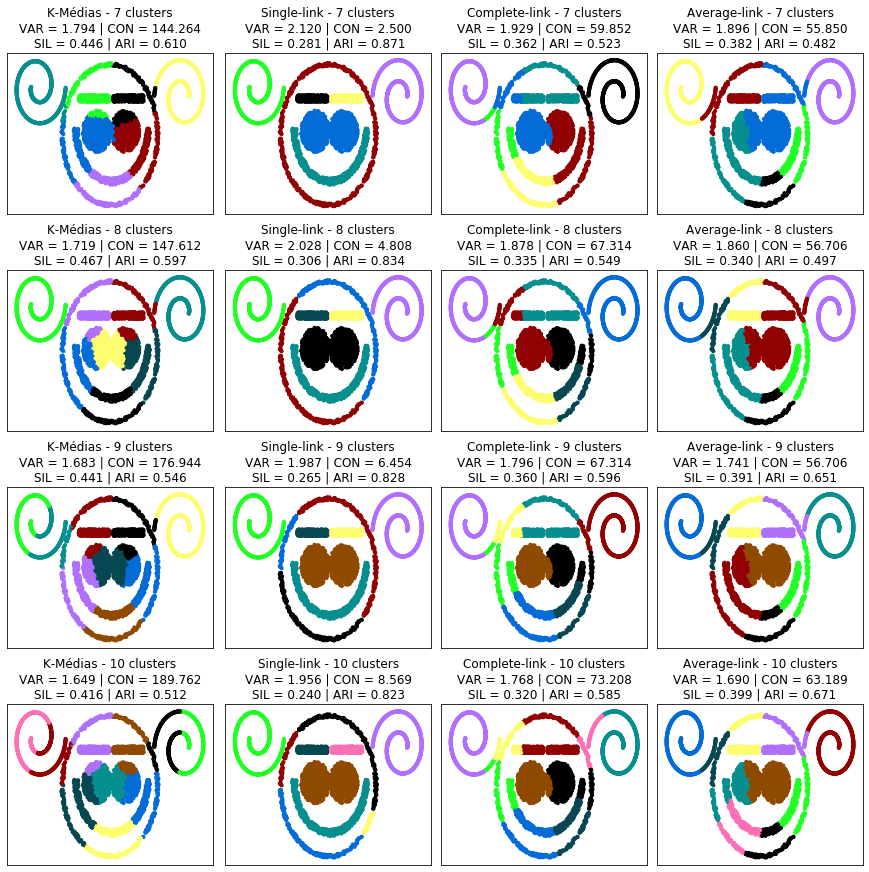

Var. Intracluster (VAR)  Conectividade (CON)  \
7  K-Médias                      1.793553           144.263889   
   Single-link                   2.120454             2.500000   
   Complete-link                 1.928940            59.852381   
   Average-link                  1.895587            55.849603   
8  K-Médias                      1.718671           147.611905   
   Single-link                   2.027844             4.807937   
   Complete-link                 1.878038            67.313889   
   Average-link                  1.860216            56.706349   
9  K-Médias                      1.683125           176.944444   
   Single-link                   1.987237             6.453571   
   Complete-link                 1.796018            67.313889   
   Average-link                  1.740770            56.706349   
10 K-Médias                      1.648615           189.762302   
   Single-link                   1.955846             8.568651   
   Complete-link                 1.768188            73.207540   
   Average-link                  1.690359            63.188889   

                  Silhueta (SIL)  Ind. Rand Corrigido (ARI)  
7  K-Médias             0.446246                   0.609617  
   Single-link          0.281141                   0.870771  
   Complete-link        0.362253                   0.523428  
   Average-link         0.382105                   0.482375  
8  K-Médias             0.467077                   0.596518  
   Single-link          0.306324                   0.834455  
   Complete-link        0.335382                   0.548519  
   Average-link         0.340474                   0.496758  
9  K-Médias             0.440542                   0.545914  
   Single-link          0.265210                   0.827667  
   Complete-link        0.360200                   0.595541  
   Average-link         0.391419                   0.651417  
10 K-Médias             0.416056                   0.511617  
   Single-link          0.240473                   0.822741  
   Complete-link        0.319617                   0.585376  
   Average-link         0.399423                   0.671314

In [18]:
results_monkey = evaluate_clusters(dataset=monkey, clusters_sizes=range(7, 11))
display(results_monkey)

---
### Entendendo melhor os índices

É esperado que os experimentos acima tenham colaborado para o entendimento dos diferentes critérios e índices da análise de agrupamento. Ainda assim, falsas impressões sobre os índices podem ter sido formadas. Dessa forma, é sempre importante ampliar os estudos sobre o funcionamento de cada um deles.

#### Variância Intracluster

Como percebido acima, a variância intracluster (VAR) não pode ser utilizada para encontrar o melhor algoritmo em todos os casos, apenas naquele cujas estruturas reais são compactas.

Em adição, embora pareça correto afirmar que os melhores agrupamentos são aqueles que minimizam a variância intracluster, deve-se atentar ao fato que **quanto maior o número de _clusters_ da partição, menor a variância intracluster**. Uma partição sem variância (VAR $= 0$) só pode ser alcançada quando cada objeto pertence a um _cluster_ individualmente, ou quando todos os objetos de um mesmo _cluster_ são idênticos, como pode ser visto nos gráficos abaixo.

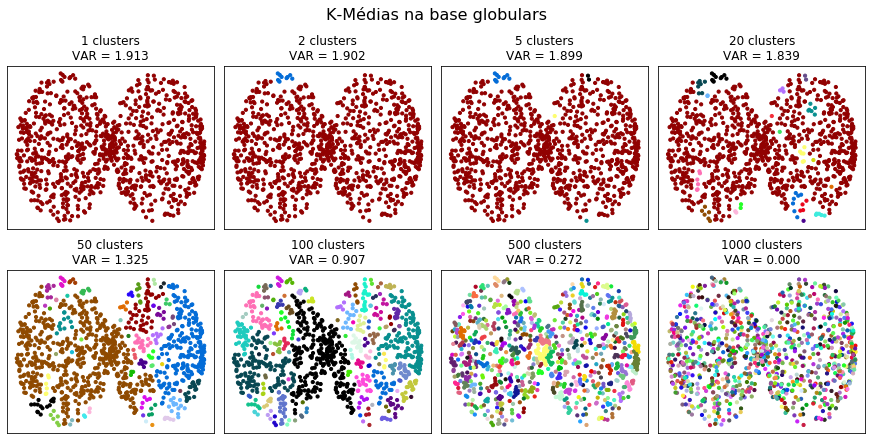

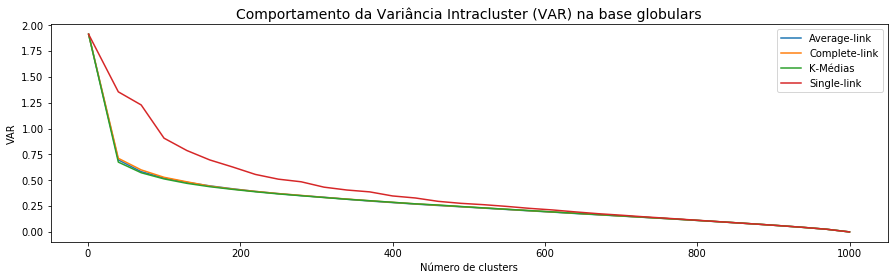

In [19]:
partitions = [1, 2, 5, 20, 50, 100, 500, 1000]
vars_ = list()
cluster_labels = list()
for i, n_clusters in enumerate(partitions, start=1):
    print('{}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='single')
    pred_clusters = model.fit_predict(globulars[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
    vars_.append(intracluster_variance(globulars[['d1', 'd2']], pred_clusters))
plot_multiple_partitions(
    globulars, cluster_labels, nrows=2, ncols=4, suptitle='K-Médias na base globulars',
    subtitles=['{} clusters\nVAR = {:.3f}'.format(c, i) for c, i in zip(partitions, vars_)]
)


partitions = [1] + list(range(40, len(globulars)+1, 30))
models = {
    'K-Médias': KMeans(),
    'Single-link': AgglomerativeClustering(linkage='single'),
    'Complete-link': AgglomerativeClustering(linkage='complete'),
    'Average-link': AgglomerativeClustering(linkage='average')
}
vars_ = {m: list() for m in models.keys()}
for i, n_clusters in enumerate(partitions, start=1):
    print('{:02}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)    
    for m, model in models.items():
        model.n_clusters = n_clusters
        pred_clusters = model.fit_predict(globulars[['d1', 'd2']])
        vars_[m].append(intracluster_variance(globulars[['d1', 'd2']], pred_clusters))
plt.figure(figsize=(15,4))
for m in sorted(models.keys()):
    plt.plot(partitions, vars_[m], label=m)
plt.title('Comportamento da Variância Intracluster (VAR) na base globulars', fontsize=14)
plt.xlabel('Número de clusters')
plt.ylabel('VAR')
plt.legend(loc='upper right')
plt.show()

##### Conectividade

Assim como ocorre na VAR, a conectividade não pode ser utilizada nem para a decisão do melhor algoritmo de agrupamento (visto que isso depende da estrutura real dos objetos), nem para a decisão do número correto de _clusters_.

É importante se atentar que, **quanto menor o número de _clusters_ em uma partição, menor sua conectividade**. Uma partição totalmente conectada (CON $= 0$) é aquela em que todos os objetos fazem parte de um mesmo _cluster_.

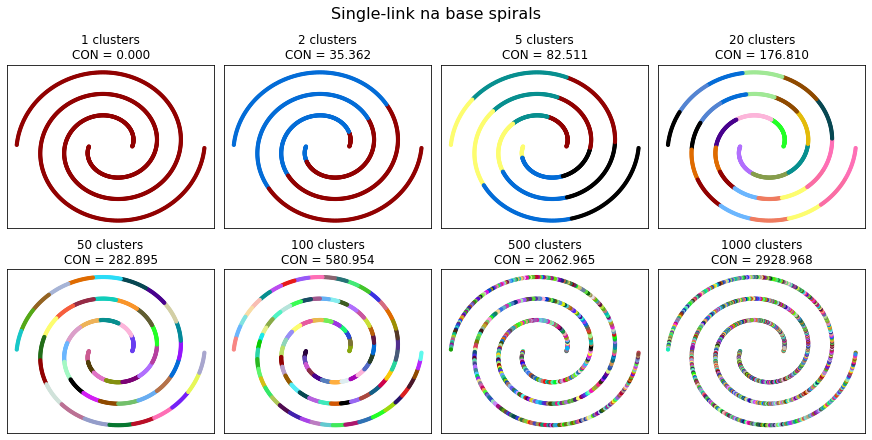

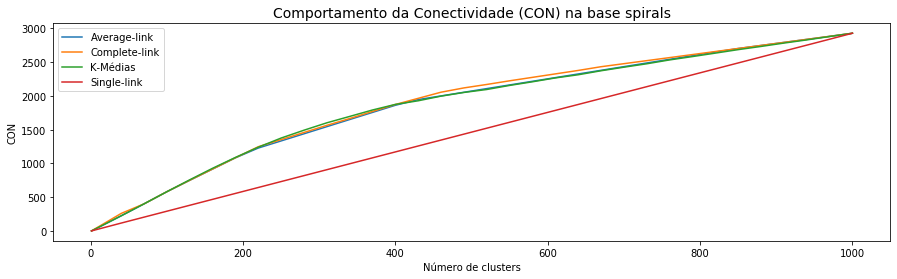

In [20]:
partitions = [1, 2, 5, 20, 50, 100, 500, 1000]
cons = list()
cluster_labels = list()
for i, n_clusters in enumerate(partitions, start=1):
    print('{}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)
    model = KMeans(n_clusters=n_clusters)#, linkage='single')
    pred_clusters = model.fit_predict(spirals[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
    cons.append(connectivity(spirals[['d1', 'd2']], pred_clusters, 10))
plot_multiple_partitions(
    spirals, cluster_labels, nrows=2, ncols=4, suptitle='Single-link na base spirals',
    subtitles=['{} clusters\nCON = {:.3f}'.format(c, i) for c, i in zip(partitions, cons)]
)


partitions = [1] + list(range(40, len(spirals)+1, 30))
models = {
    'K-Médias': KMeans(),
    'Single-link': AgglomerativeClustering(linkage='single'),
    'Complete-link': AgglomerativeClustering(linkage='complete'),
    'Average-link': AgglomerativeClustering(linkage='average')
}
cons = {m: list() for m in models.keys()}
for i, n_clusters in enumerate(partitions, start=1):
    print('{:02}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)
    for m, model in models.items():
        model.n_clusters = n_clusters
        pred_clusters = model.fit_predict(spirals[['d1', 'd2']])
        cons[m].append(connectivity(spirals[['d1', 'd2']], pred_clusters, 10))
plt.figure(figsize=(15,4))
for m in sorted(models.keys()):
    plt.plot(partitions, cons[m], label=m)
plt.title('Comportamento da Conectividade (CON) na base spirals', fontsize=14)
plt.xlabel('Número de clusters')
plt.ylabel('CON')
plt.legend(loc='upper left')
plt.show()

##### Silhueta e índice Rand

Diferente da variância intracluster e da conectividade, a silhueta e o índice Rand não possuem crescimento ou queda contínuo de acordo com o aumento no número de _clusters_. Para cada partição, é possível obter uma silhueta e um índice Rand diferente, que pode cair ou subir e acordo com a alteração no número de *clusters*.

Entretanto, não se pode pensar que, por esse motivo, a silhueta é o índice certo para escolher o número de _clusters_. Como já foi visto no conjunto `spirals`, **a silhueta é só mais uma forma de medida, mensurando um critério específico dentro das estruturas da partição**.

Da mesma forma, é importante perceber que **o índice Rand é aquele que encontra a partição mais parecida com uma hipótese pré-estabelecida, mas essa partição não possui, necessariamente, o mesmo número de _clusters_ da real**.

Nos gráficos abaixo, com a aplicação dos algoritmos na base `monkey`, é possível visualizar estas duas afirmações. Nos primeiros gráficos, em que as partições foram geradas com o K-Médias, percebe-se que a silhueta encontrou o número esperado de _clusters_ (seu maior valor, $0.467$, foi para a partição de 8 *clusters*), mas o índice Rand apontou que as partições com 7, 10 e 11 encontraram um agrupamento mais parecido com o original. Adicionalmente, o valor de silhueta para a partição real (último gráfico) foi o mais baixo de todos, mesmo sendo aquele que alcançaria valor máximo no índice Rand.

Nos dois gráficos de linha no final, percebe-se que, para os algoritmos Single-link e K-Médias, a silhueta encontrou o número esperado de *clusters*, mas o mesmo não aconteceu para os algoritmos Average-link e Complete-link. Já para o índice Rand, cada algoritmo alcançou o maior valor em partições de tamanhos diferentes.

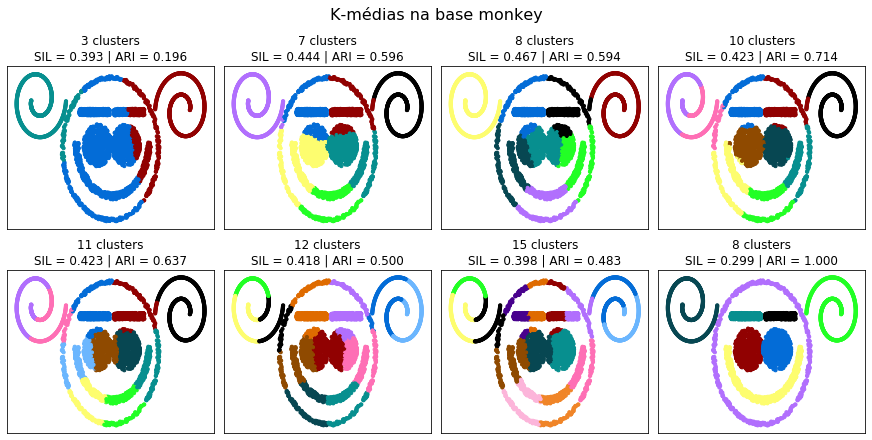

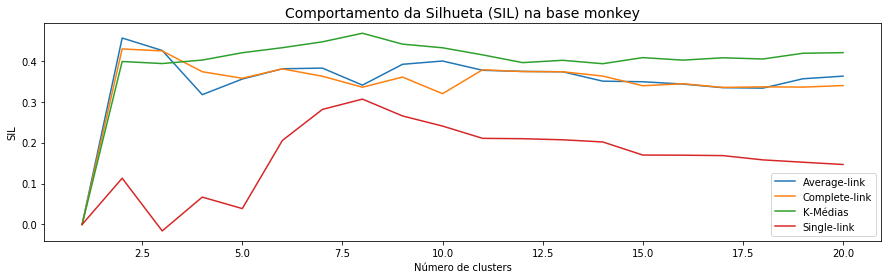

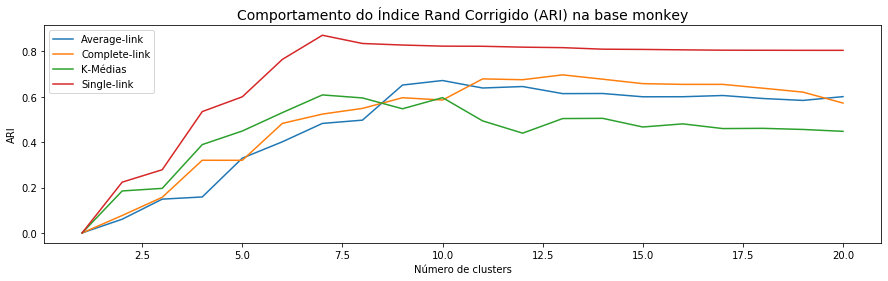

In [21]:
partitions = [3, 7, 8, 10, 11, 12, 15]
sils = list()
aris = list()
cluster_labels = list()
for i, n_clusters in enumerate(partitions, start=1):
    print('{}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)
    model = KMeans(n_clusters=n_clusters, init='random', random_state=3)
    pred_clusters = model.fit_predict(monkey[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
    sils.append(silhouette_score(monkey[['d1', 'd2']], pred_clusters))
    aris.append(adjusted_rand_score(monkey['cluster'], pred_clusters))
cluster_labels.append(monkey['cluster'])
partitions.append(monkey.n_clusters)
sils.append(silhouette_score(monkey[['d1', 'd2']], monkey['cluster']))
aris.append(adjusted_rand_score(monkey['cluster'], monkey['cluster']))
plot_multiple_partitions(
    monkey, cluster_labels, nrows=2, ncols=4, suptitle='K-médias na base monkey',
    subtitles=['{} clusters\nSIL = {:.3f} | ARI = {:.3f}'.format(c, s, a) for c, s, a in zip(partitions, sils, aris)]
)

partitions = list(range(1, 21))
models = {
    'K-Médias': KMeans(),
    'Single-link': AgglomerativeClustering(linkage='single'),
    'Complete-link': AgglomerativeClustering(linkage='complete'),
    'Average-link': AgglomerativeClustering(linkage='average')
}
sils = {m: list() for m in models.keys()}
aris = {m: list() for m in models.keys()}
for i, n_clusters in enumerate(partitions, start=1):
    print('{:02}/{} partições geradas...'.format(i, len(partitions)), end='\r', flush=True)
    for m, model in models.items():
        model.n_clusters = n_clusters
        pred_clusters = model.fit_predict(monkey[['d1', 'd2']])
        sils[m].append(silhouette_score(monkey[['d1', 'd2']], pred_clusters) if sum(pred_clusters) > 0 else 0)
        aris[m].append(adjusted_rand_score(monkey['cluster'], pred_clusters))

plt.figure(figsize=(15,4))
for m in sorted(models.keys()):
    plt.plot(partitions, sils[m], label=m)
plt.title('Comportamento da Silhueta (SIL) na base monkey', fontsize=14)
plt.xlabel('Número de clusters')
plt.ylabel('SIL')
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(15,4))
for m in sorted(models.keys()):
    plt.plot(partitions, aris[m], label=m)
plt.title('Comportamento do Índice Rand Corrigido (ARI) na base monkey', fontsize=14)
plt.xlabel('Número de clusters')
plt.ylabel('ARI')
plt.legend(loc='upper left')
plt.show()

## Conclusão

Neste *notebook*, foram aplicados algoritmos de agrupamento e índices de avaliação de partições para apresentar um processo completo de análise de agrupamento.

Os resultados alcançados mostraram que não há um algoritmo certo para todo conjunto de dados. Como cada algoritmo possui uma estratégia de agrupamento, encontrando _clusters_ de formato específico, o algoritmo mais apropriado para um problema depende muito do formato das estruturas reais dos dados.

Da mesma forma, não existe um índice que encontra a partição mais apropriada. O índice Rand é o que aponta qual partição gerada mais se assemelha com uma real, mas, em cenários reais, essa partição real é desconhecida. Utilizar o índice Rand para comparar a partição gerada com uma hipótese pré-estabelecida pode gerar confusão caso a hipótese esteja errada. 

Os demais índices apontam o quanto os agrupamentos gerados obedecem a um determinado critério. Utilizá-los para comparar partições apenas evidencia qual é aquela cujas estruturas mais respeitam uma característica específica.

Ao término deste *notebook*, espera-se que o leitor tenha entendido como realizar um processo de análise de agrupamento, da aplicação dos algoritmos até a avaliação. É esperado que tenha ficado claro que não existe uma partição certa, ou um algoritmo ou índice melhor que o outro. Por se tratar de um problema não supervisionado, a análise de agrupamento é bastante complexa, e depende de muita análise para entender os resultados gerados.

---
---
## Explore o _notebook_!

Agora é sua vez! Retorne ao começo deste _notebook_ e faça mudanças nos códigos para aprender ainda mais sobre análise de agrupamento!

A seguir, algumas ideias de mudanças são sugeridas...

### Teste com bases de dados diferentes

No diretório `datasets`, encontra-se mais um conjunto de dados, `d23c2sc13`. A base possui 3 versões, cada uma com uma partição diferente, com 2, 5 e 13 _clusters_. Os grupos possuem estruturas variadas, mesclando _clusters_ globulares com encadeados.

Execute os experimentos acima novamente, e veja como cada algoritmo se comporta sobre estes objetos.

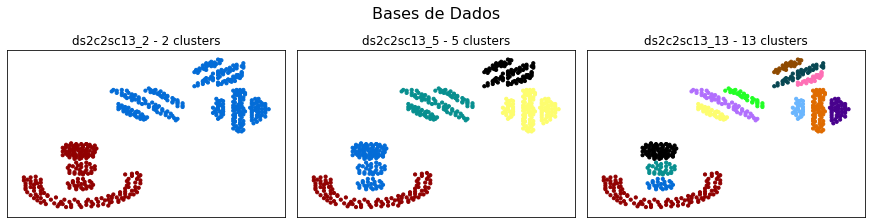

In [22]:
ds2c2sc13_2 = load_dataset('ds2c2sc13_2')
ds2c2sc13_5 = load_dataset('ds2c2sc13_5')
ds2c2sc13_13 = load_dataset('ds2c2sc13_13')
datasets = [ds2c2sc13_2, ds2c2sc13_5, ds2c2sc13_13]
plot_multiple_datasets(datasets, suptitle='Bases de Dados', nrows=1, ncols=3)

### Descubra outras medidas de distância e similaridade

A biblioteca `scipy` possui [diversas medidas diferentes de distância e similaridade](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html) para ser aplicada sobre vetores. Algumas para vetores numéricos, como os utilizados neste *notebook*, outras para vetores binários.

Pesquise sobre e execute outras medidas sobre os vetores $x_0$ e $x_1$, da Seção **Medidas de similaridade**. Gere vetores binários se necessário.

In [23]:
# Vetores numéricos
from scipy.spatial.distance import braycurtis
from scipy.spatial.distance import canberra
from scipy.spatial.distance import mahalanobis

# Vetores binários
from scipy.spatial.distance import dice
from scipy.spatial.distance import hamming
from scipy.spatial.distance import jaccard
from scipy.spatial.distance import rogerstanimoto
from scipy.spatial.distance import russellrao
from scipy.spatial.distance import sokalmichener
from scipy.spatial.distance import sokalsneath
from scipy.spatial.distance import yule

### Execute as medidas de distância para vetores com mais de 2 dimensões

No *notebook*, as medidas de distância e similaridade foram executadas apenas para vetores de 2 dimensões. Execute-as também para vetores com mais de 2 dimensões, e tente calcular o resultado antes de executar as funções, para garantir o entendimento.

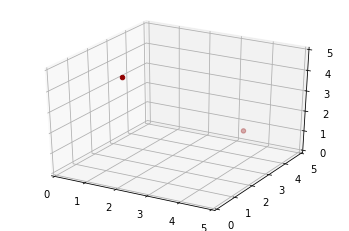

In [24]:
from mpl_toolkits import mplot3d

x = np.array([[1.0, 2.0, 4.0],
              [4.0, 3.5, 1.5]])

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(x[:,0], x[:,1], x[:,2], c='#910101')
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_zlim(0, 5)
plt.show()

### Altere a medida de distância nos algoritmos de agrupamento

Vários dos algoritmos executados neste _notebook_ calculam a distância entre os objetos para realizar o agrupamento. Essa distância pode ser escolhida entre qualquer uma das estudadas, bastando passar como parâmetro do algoritmo, ou pré-calculando a matriz de distância e usando ela como entrada. Por padrão, todos os algoritmos utilizam distância euclidiana.

Estude os algoritmos na documentação da biblioteca `scikit-learn`, veja quais aceitam diferentes medidas de distância e observe os diferentes resultados de agrupamento para múltiplas medidas de distância diferentes.

**Nota sobre a implementação:** no exemplo abaixo, a distância Euclidiana e a similaridade de cosseno foram passadas como parâmetro `affinity` do algoritmo. A distância de Chebyshev, como não se encontra como possível opção de `affinity`, foi pré-computada (`afinnity='precomputed'`).

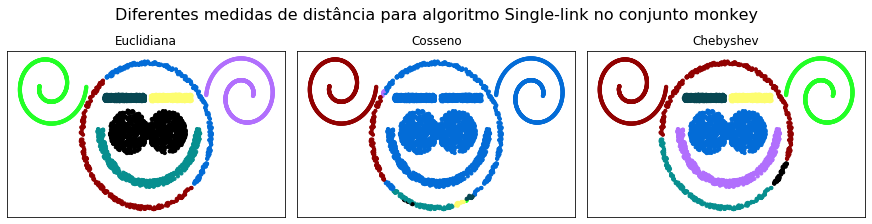

In [25]:
sl_euclidean = AgglomerativeClustering(n_clusters=8, linkage='single', affinity='euclidean')
sl_cosine = AgglomerativeClustering(n_clusters=8, linkage='single', affinity='cosine')
sl_chebyshev = AgglomerativeClustering(n_clusters=8, linkage='single', affinity='precomputed')

from scipy.spatial.distance import pdist, squareform
chebyshev_distances = squareform(pdist(monkey[['d1', 'd2']], metric='chebyshev'))

euclidean_clusters = sl_euclidean.fit_predict(monkey[['d1', 'd2']])
cosine_clusters = sl_cosine.fit_predict(monkey[['d1', 'd2']])
chebyshev_clusters = sl_chebyshev.fit_predict(chebyshev_distances)

plot_multiple_partitions(
    dataset=monkey, cluster_labels=[euclidean_clusters, cosine_clusters, chebyshev_clusters],
    nrows=1, ncols=3, subtitles=['Euclidiana', 'Cosseno', 'Chebyshev'],
    suptitle='Diferentes medidas de distância para algoritmo Single-link no conjunto monkey'
)

### Explore mais algoritmos de agrupamento

A biblioteca `scikit-learn` possui [diversos algoritmos de agrupamento implementados](https://scikit-learn.org/stable/modules/clustering.html), de uso bastante semelhante aos utilizados neste _notebook_.

Verifique os resultados obtidos se outros algoritmos fossem executados.

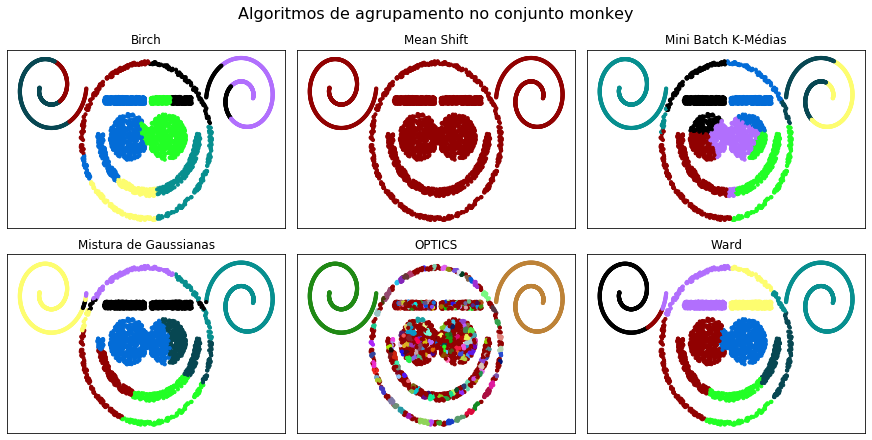

In [26]:
from sklearn.cluster import AgglomerativeClustering, Birch, MeanShift, MiniBatchKMeans, OPTICS
from sklearn.mixture import GaussianMixture

models = {    
    'Birch': Birch(n_clusters=8),
    'Mean Shift': MeanShift(),
    'Mini Batch K-Médias': MiniBatchKMeans(),
    'Mistura de Gaussianas': GaussianMixture(n_components=8),
    'OPTICS': OPTICS(),
    'Ward': AgglomerativeClustering(n_clusters=8, linkage='ward')
}

cluster_labels = list()
for model_name, model in sorted(models.items()):
    pred_clusters = model.fit_predict(monkey[['d1', 'd2']])
    cluster_labels.append(pred_clusters)
    
plot_multiple_partitions(
    monkey, cluster_labels=cluster_labels, nrows=2, ncols=3,
    suptitle='Algoritmos de agrupamento no conjunto monkey',
    subtitles=sorted(models.keys())
)

### Utilize outros índices de avaliação, ou outras formas de avaliar

A bilioteca `scikit-learn` possui [diversos outros índices de avaliação para agrupamento](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics.cluster). Estude alguns destes índices, aplique sobre as partições encontradas e faça comparações entre os algoritmos.

Adicionalmente, é possível avaliar os algoritmos de agrupamento com base em outras características, como estabilidade e tempo para execução. A documentação da biblioteca HDBSCAN possui [uma comparação de algoritmos bastante interessante](https://hdbscan.readthedocs.io/en/latest/comparing_clustering_algorithms.html), e diferente da realizada nesse experimento.

In [27]:
# Critérios internos
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Critérios externos
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import completeness_score
from sklearn.metrics import fowlkes_mallows_score
from sklearn.metrics import homogeneity_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import v_measure_score